# Resume / Candidate Screening System

## Machine Learning Internship Task 3

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string

import nltk
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to C:\Users\Anton
[nltk_data]     joseph\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Load Dataset

In [3]:
df = pd.read_csv("../data/Resume.csv")

In [4]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [5]:
df.shape

(2484, 4)

In [6]:
df.columns

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [8]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df_ml = df[["Resume_str", "Category"]].copy()

df_ml.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [11]:
df_ml.isnull().sum()

Resume_str    0
Category      0
dtype: int64

In [12]:
df_ml.duplicated().sum()

np.int64(2)

In [13]:
def clean_resume(text):

    text = str(text).lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()

    stop_words = set(stopwords.words("english"))

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [14]:
df_ml["Clean_Resume"] = df_ml["Resume_str"].apply(clean_resume)

df_ml.head()

,Resume_str,Category,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary 20 years experience recrui...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlights hr skills hr depar...


In [15]:
job_description = """
Looking for a Data Scientist with experience in Python,
Machine Learning,
Data Analysis,
SQL,
Deep Learning,
Statistics,
Pandas,
NumPy,
Scikit-learn,
Data Visualization.
"""

In [16]:
vectorizer = TfidfVectorizer(max_features=5000)

resume_vectors = vectorizer.fit_transform(df_ml["Clean_Resume"])

job_vector = vectorizer.transform([clean_resume(job_description)])

In [17]:
similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

In [18]:

df_ml["Similarity Score"] = similarity_scores

df_ml = df_ml.sort_values(
    by="Similarity Score",
    ascending=False
)

df_ml.head(10)


,Resume_str,Category,Clean_Resume,Similarity Score
1218,Pavithra Shetty Summary ...,CONSULTANT,pavithra shetty summary customeroriented princ...,0.389082
1762,ENGINEERING AND QUALITY TECHNICIAN ...,ENGINEERING,engineering quality technician career overview...,0.356138
1339,DATA ANALYST Professional Summa...,AUTOMOBILE,data analyst professional summary industrial s...,0.268958
926,SOFTWARE DEVELOPER Professi...,AGRICULTURE,software developer professional summary enthus...,0.234420
2153,"CORPORATE BANKING ASSISTANT, INTERN ...",BANKING,corporate banking assistant intern objective d...,0.222598
331,MASTER DATA MANAGER Experie...,INFORMATION-TECHNOLOGY,master data manager experience master data man...,0.208053
1303,SENIOR DIGITAL MARKETING ANALYST ...,DIGITAL-MEDIA,senior digital marketing analyst summary highl...,0.207817
1091,SALES ENGINEER Summary I...,SALES,sales engineer summary currently looking advan...,0.202551
929,"VP, PRINCIPAL Summary I am ...",AGRICULTURE,vp principal summary highly skilledgrowth mind...,0.201300
1040,SALES COORDINATOR Summary Cu...,SALES,sales coordinator summary current ms data anal...,0.197689


In [19]:
skills = [
    "python",
    "sql",
    "machine learning",
    "deep learning",
    "pandas",
    "numpy",
    "scikit",
    "statistics",
    "data analysis",
    "excel"
]

In [20]:
def extract_skills(text):

    text = text.lower()

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

In [21]:
df_ml["Extracted Skills"] = df_ml["Clean_Resume"].apply(extract_skills)

In [22]:
required_skills = set(skills)

In [23]:
def skill_gap(found):

    found = set(found)

    return list(required_skills - found)


In [24]:
df_ml["Missing Skills"] = df_ml["Extracted Skills"].apply(skill_gap)

In [25]:
df_ml[[
    "Category",
    "Similarity Score",
    "Extracted Skills",
    "Missing Skills"
]].head(10)

,Category,Similarity Score,Extracted Skills,Missing Skills
1218,CONSULTANT,0.389082,"[python, sql, machine learning, data analysis]","[numpy, statistics, deep learning, excel, pand..."
1762,ENGINEERING,0.356138,"[python, sql, machine learning, pandas, statis...","[deep learning, numpy, scikit]"
1339,AUTOMOBILE,0.268958,"[python, sql, pandas, numpy, scikit, statistic...","[deep learning, machine learning]"
926,AGRICULTURE,0.234420,"[python, sql, pandas, scikit, excel]","[numpy, data analysis, deep learning, machine ..."
2153,BANKING,0.222598,"[python, sql, machine learning]","[pandas, numpy, data analysis, deep learning, ..."
331,INFORMATION-TECHNOLOGY,0.208053,"[python, sql, data analysis, excel]","[numpy, statistics, deep learning, machine lea..."
1303,DIGITAL-MEDIA,0.207817,"[python, sql, excel]","[pandas, numpy, data analysis, deep learning, ..."
1091,SALES,0.202551,"[sql, excel]","[pandas, numpy, data analysis, deep learning, ..."
929,AGRICULTURE,0.201300,"[python, sql, pandas]","[numpy, data analysis, deep learning, machine ..."
1040,SALES,0.197689,"[machine learning, statistics, data analysis, ...","[numpy, sql, deep learning, python, pandas, sc..."


In [26]:
df_ml.to_csv("../notebook/ranked_candidates.csv", index=False)

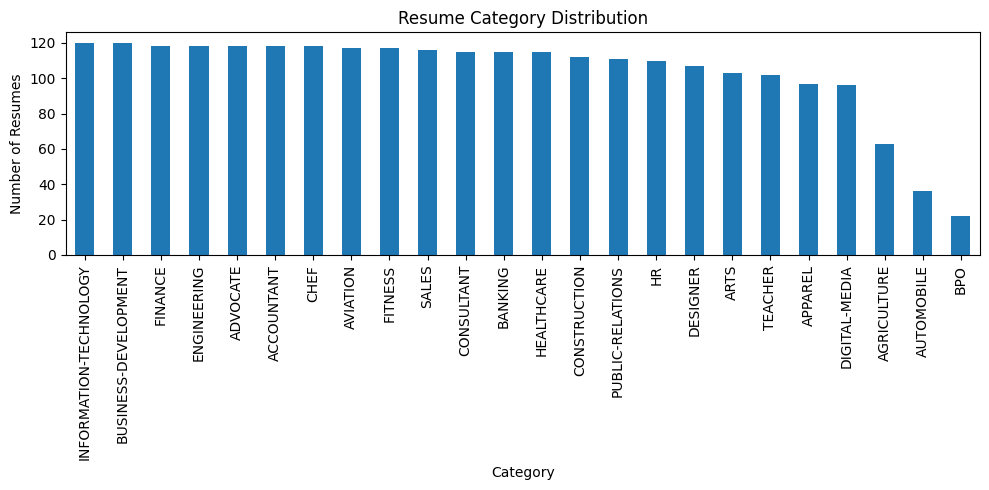

In [27]:
plt.figure(figsize=(10,5))

df_ml["Category"].value_counts().plot(kind="bar")

plt.title("Resume Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Resumes")

plt.tight_layout()

plt.savefig("../images/category_distribution.png", dpi=300)

plt.show()

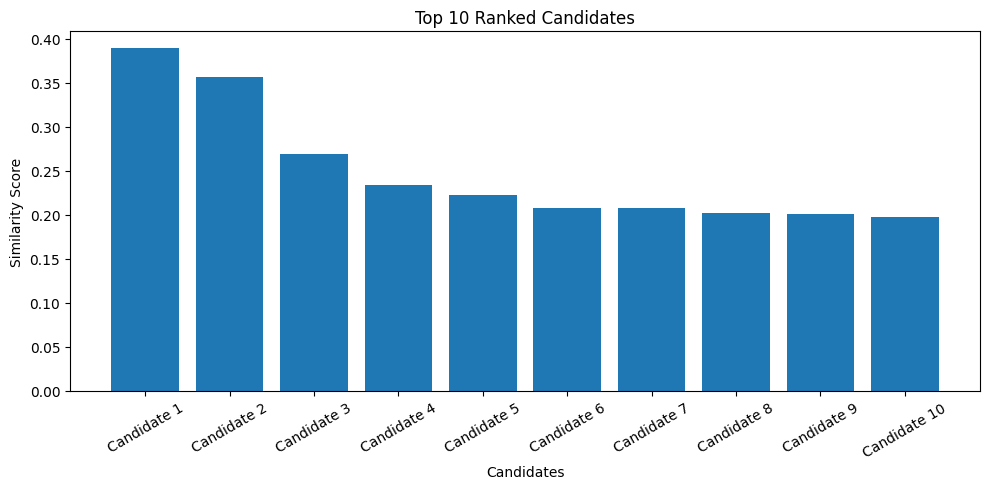

In [29]:
top10 = df_ml.head(10)

plt.figure(figsize=(10,5))

plt.bar(range(10), top10["Similarity Score"])

# Candidate labels instead of categories
candidate_labels = [f"Candidate {i}" for i in range(1, 11)]

plt.xticks(range(10), candidate_labels, rotation=30)

plt.title("Top 10 Ranked Candidates")
plt.xlabel("Candidates")
plt.ylabel("Similarity Score")

plt.tight_layout()

plt.savefig("../images/top_candidates.png", dpi=300)

plt.show()

## Business Conclusion

This Resume Screening System compares resumes with a given job description using Natural Language Processing (NLP) techniques. Resumes are cleaned, converted into TF-IDF vectors, and compared with the job description using cosine similarity. Candidates are ranked based on similarity scores, and missing skills are identified to help recruiters make faster and more informed hiring decisions.